In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
from common.trajectory_controller import TrajectoryController
from common.activation_patcher import ActivationPatcher

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [4]:
# Base configuration
CKPT_PATH = 'ckpts/cartpole-swingup-3.pt'
override_cfg = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,  # Disable video to speed up sweep
    record_planning=False,  # Focus on episode data
)

with initialize(config_path="../tdmpc2/tdmpc2", version_base=None):
    cfg = compose(config_name="config")
    OmegaConf.set_struct(cfg, False)
    cfg = OmegaConf.merge(cfg, override_cfg)

# Parse config
cfg = parse_cfg(cfg)
set_seed(cfg.seed)

cfg.initial_state = {
    'qpos': {
        'slider': 0,  #cart position
        'hinge_1': 0,  # pole angle
    },
}

env = make_env(cfg)

print("\nLoading agent...")
agent = TDMPC2(cfg)

# Optionally load checkpoint
if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
    print(f"Loading checkpoint: {cfg.checkpoint}")
    agent.load(cfg.checkpoint)


Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: ckpts/cartpole-swingup-3.pt


## load directions

In [5]:
import pickle

# Load the learned steering directions from the lasso results
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/25-12-04-latent_intervention_control/w_action_lasso_results.pkl',
        'rb') as f:
    w_lasso_results = pickle.load(f)
action_direction = w_lasso_results[0]['coef'].squeeze()

<StemContainer object of 3 artists>

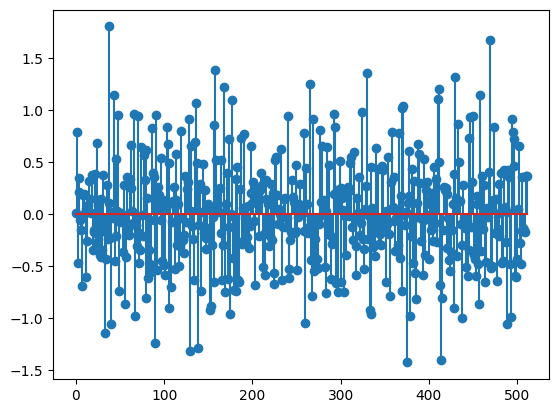

In [6]:
plt.stem(action_direction)

In [7]:
action_direction_tensor = torch.from_numpy(action_direction)


In [8]:
# cart_position = np.concatenate(
#     [np.linspace(0, -1, 160, endpoint=False),
#      np.linspace(-1, 1, 500 - 160)])

# cos_pole_angle = np.ones_like(cart_position)
# sin_pole_angle = np.zeros_like(cart_position)
# cart_velocity = np.zeros_like(cart_position)
# pole_angular_velocity = np.zeros_like(cart_position)

# obs = np.stack([
#     cart_position, cos_pole_angle, sin_pole_angle, cart_velocity,
#     pole_angular_velocity
# ],
#                axis=-1)


In [9]:
# 4. Create target trajectory
target_trajectory = torch.zeros(500, 5)
target_trajectory[:, 0] = torch.cat(
    [torch.linspace(0, -0.5, 160),
     torch.linspace(-0.5, 0.5, 500 - 160)])


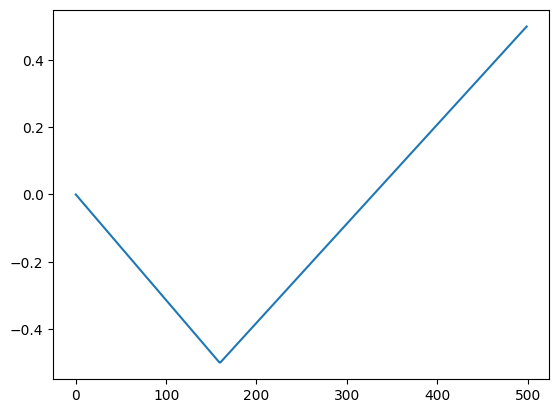

In [10]:
plt.plot(target_trajectory[:, 0])

Setting up hooks for encoder_output
ActivationPatcher initialized with hooks on:
  - encoder_output


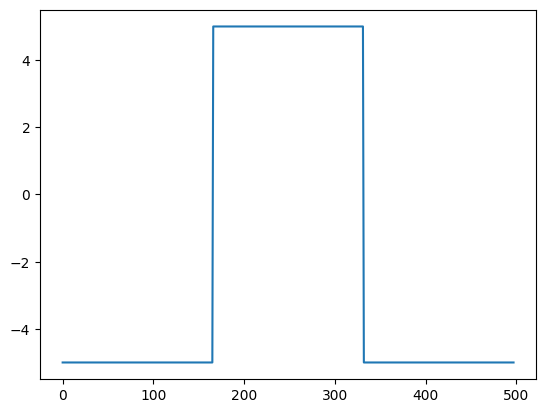

In [24]:
# 1. Setup patcher
patcher = ActivationPatcher(
    agent.model,
    modules_to_hook=['encoder_output'],
    renormalize_after_intervention=False,
)

# 2. Your learned steering directions (from probing/analysis)
steering_directions = {
    'cart_pos': action_direction_tensor,  # shape: (latent_dim,)
    #'angle': angle_direction,          # shape: (latent_dim,)
}

# 3. Which observation indices correspond to each feature
# feature_indices = {
#     'cart_pos': 0,  # obs[0] is cart position
#     #'angle': (1, 2),         # obs[1:3] is (cos, sin) of angle
# }

# 4. Create target trajectory
# 4. Create target trajectory
target_trajectory = torch.zeros(500, 5)
target_trajectory[:, 0] = torch.cat(
    [torch.linspace(0, -.8, 160),
     torch.linspace(-.8, 0.0, 500 - 160)])

#target_trajectory[:, 1] = 1.0  # Keep upright (cos=1)

# 5. Create controller
# controller = TrajectoryController(
#     patcher=patcher,
#     target_trajectory=target_trajectory,
#     steering_directions=steering_directions,
#     feature_indices=feature_indices,
#     control_mode='proportional',  # or 'pid' for smoother tracking
#     gain=5.0,  # tune this!
#     max_steering_magnitude=5.0,
# )

# controller = TrajectoryController(
#     patcher=patcher,
#     target_trajectory=target_trajectory,
#     fixed_steering_direction=action_direction_tensor,  # Shape: (latent_dim,)
#     feature_indices={'cart_pos': 0},  # Which features to compute error from
#     control_mode='magnitude_only',
#     gain=0.9,
#     error_aggregation='sum',  # 'sum', 'mean', or 'norm'
# )

# Create a magnitude sequence (one value per timestep)
num_steps = 500
magnitudes = torch.cat([
    torch.zeros(num_steps // 3) - 5,
    torch.zeros(num_steps // 3) + 5,
    torch.zeros(num_steps // 3) - 5
])
#magnitudes = torch.zeros(num_steps) + 5  # Ramp up
# Or use a computed sequence from an oracle, optimal control, etc.

plt.plot(magnitudes)

In [25]:
controller = TrajectoryController(
    patcher=patcher,
    target_trajectory=torch.zeros(num_steps, 5),  # Dummy, not used for control
    fixed_steering_direction=action_direction_tensor,  # Shape: (latent_dim,)
    prescribed_magnitudes=magnitudes,  # Shape: (num_steps,)
    control_mode='open_loop',
)

# # Run episode (observation doesn't affect steering)
# obs = env.reset()
# for step in range(num_steps):
#     controller.update(obs, step)  # Loads magnitudes[step] * direction
#     action = agent.act(obs, t0=(step==0), eval_mode=True)
#     obs, _, done, _ = env.step(action)
# # 6. Run episode
# obs = env.reset()
# for step in tqdm(range(500)):
#     controller.update(obs, step)  # Computes and stores steering
#     action = agent.act(obs, t0=(step == 0), eval_mode=True)
#     obs, _, done, _ = env.step(action)

# controller.reset()

obs = env.reset()
actions = []
obs_list = []
controller_info_list = []
for step in tqdm(range(500)):
    controller_info = controller.update(obs,
                                        step)  # Computes and stores steering
    action = agent.act(obs, t0=(step == 0), eval_mode=True)
    obs, _, done, _ = env.step(action)
    actions.append(action)
    obs_list.append(obs)
    controller_info_list.append(controller_info)
actions = np.array(actions)
obs_list = np.array(obs_list)

Added intervention at: encoder_output (active when t >= 0)
Normalizing fixed steering direction
TrajectoryController initialized:
  Mode: open_loop
  Target trajectory shape: (500, 5)
  Features: []
  Gain (Kp): {}
  Fixed direction shape: (512,)
  Prescribed magnitudes shape: (498,)
  Magnitude range: [-5.000, 5.000]


100%|██████████| 500/500 [00:12<00:00, 39.05it/s]


In [26]:
controller.last_steering.shape

torch.Size([512])

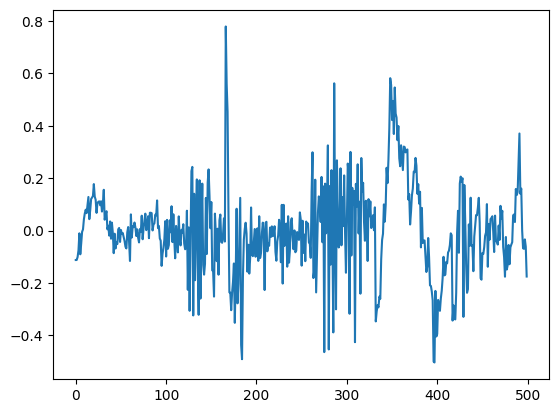

In [27]:
plt.plot(actions)

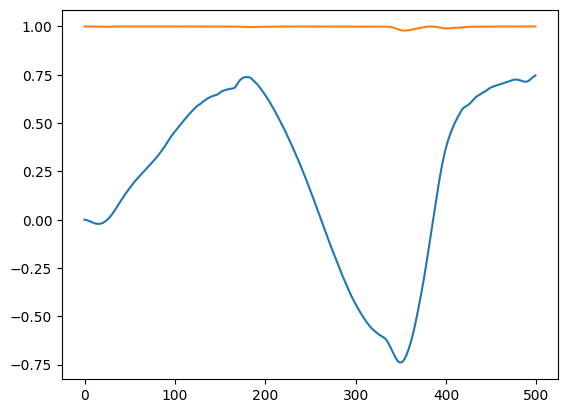

In [28]:
plt.plot(obs_list[:, 0])
plt.plot(obs_list[:, 1])

In [22]:
# z_t_list = [info_list[i]['z_t'] for i in range(len(info_list))]
# z_t = torch.stack(z_t_list)

In [29]:
from datetime import datetime

date_time = datetime.now().strftime("%Y%m%d_%H%M%S")
reconstruct_cartpole_dmcontrol(
    obs_list,
    height=320,
    width=320,
    camera_id=0,
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/clc/tracking_{date_time}.mp4')

100%|██████████| 500/500 [00:10<00:00, 45.84it/s]


Wrote 500 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/clc/tracking_20251211_170908.mp4


[array([[[ 67, 101, 134],
         [ 67, 101, 134],
         [ 67, 101, 134],
         ...,
         [ 67, 101, 134],
         [ 67, 101, 134],
         [ 67, 101, 134]],
 
        [[ 67, 100, 134],
         [ 67, 100, 134],
         [ 67, 100, 134],
         ...,
         [ 67, 100, 134],
         [ 67, 100, 134],
         [ 67, 100, 134]],
 
        [[ 67, 100, 134],
         [ 67, 100, 134],
         [ 67, 100, 134],
         ...,
         [ 67, 100, 134],
         [ 67, 100, 134],
         [ 67, 100, 134]],
 
        ...,
 
        [[ 42,  63,  86],
         [ 42,  64,  86],
         [ 43,  64,  86],
         ...,
         [ 21,  43,  64],
         [ 21,  43,  64],
         [ 21,  43,  64]],
 
        [[ 42,  63,  86],
         [ 42,  63,  86],
         [ 42,  63,  86],
         ...,
         [ 21,  43,  64],
         [ 21,  43,  64],
         [ 21,  43,  64]],
 
        [[ 42,  63,  86],
         [ 42,  63,  86],
         [ 42,  63,  86],
         ...,
         [ 21,  42,  64],
  

In [34]:
actions_original = actions
magnitudes_original = magnitudes

In [37]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm import tqdm
from datetime import datetime

actions = actions_original
magnitudes = magnitudes_original
# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
#fig.suptitle('Tracking Animation', fontsize=14, fontweight='bold')

# Set up the axes
ax1.set_xlim(0, len(magnitudes))
ax1.set_ylim(magnitudes.min() - 0.1 * abs(magnitudes.min()),
             magnitudes.max() + 0.1 * abs(magnitudes.max()))
ax1.set_xlabel('Time Step')
ax1.set_ylabel("α")
#ax1.set_title('Magnitudes')
ax1.grid(True, alpha=0.3)

ax2.set_xlim(0, len(actions))
ax2.set_ylim(actions.min() - 0.1 * abs(actions.min()),
             actions.max() + 0.1 * abs(actions.max()))
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Action')
#ax2.set_title('Actions')
ax2.grid(True, alpha=0.3)

# Initialize lines
line1, = ax1.plot([], [], 'b-', linewidth=2, label='Magnitude')
line2, = ax2.plot([], [], 'r-', linewidth=2, label='Action')

ax1.legend()
ax2.legend()

# Progress bar
pbar = tqdm(total=len(magnitudes), desc='Creating animation')


# Animation function
def animate(frame):
    line1.set_data(range(frame), magnitudes[:frame])
    line2.set_data(range(frame), actions[:frame])
    pbar.update(1)
    return line1, line2


# Create animation at 30 fps
anim = FuncAnimation(fig,
                     animate,
                     frames=len(magnitudes),
                     interval=1000 / 30,
                     blit=True,
                     repeat=False)

plt.tight_layout()

# Save animation to file
date_time = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/clc/tracking_animation_{date_time}.gif'
anim.save(output_path, writer='pillow', fps=30)
pbar.close()
plt.close(fig)

print(f"Animation saved to: {output_path}")

Creating animation:   0%|          | 0/498 [00:35<?, ?it/s]
Creating animation: 501it [01:12,  6.94it/s]

Animation saved to: /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/clc/tracking_animation_20251211_171625.gif


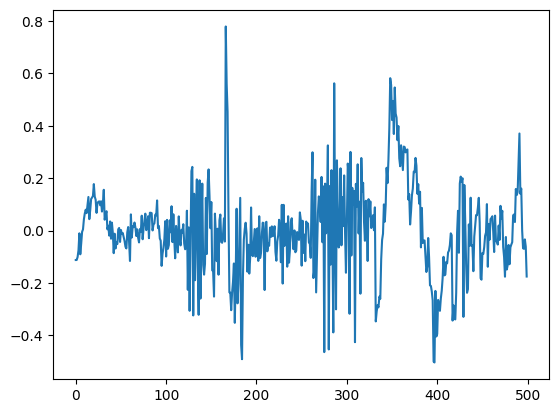